# Galactic archaeology of a synthetic m12f stellar sample

**Project notebook — Maryam Ahsan, IAstro Summer Internship 2025.** This notebook explores a supplied CSV of synthetic stars, transforms their sky coordinates and velocities into a Galactocentric frame, compares the supplied disk/halo labels through spatial, kinematic, chemical, and age distributions, trains supervised classifiers, and then examines structure within the labelled halo sample using t-SNE and clustering. The goal is to use physical clues to guide interpretation of the machine-learning results, including possible accreted substructure.

# 0. Importing Libraries

In [24]:
# Libraries

# General
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.coordinates import SkyCoord, Galactocentric, CartesianDifferential, ICRS
import astropy.units as u



# For ML
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, silhouette_score, davies_bouldin_score, calinski_harabasz_score)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler 

# 1. Collecting/Reading Data

In [25]:
# Creating a data frame
df = pd.read_csv("sample_students_m12f-lsr0.csv")

# 2. Data Engineering and Preprocessing Data

In [26]:
# Getting rid of rows with missing data
df = df.dropna(subset=['parallax', 'ra', 'dec', 'pmdec', 'pmra', 'radial_velocity', 'age', 'feh', 'alpha', 'magnesium', 'labels']) 

## 2.1 Galactocentric Coordinates and Velocities 

### 2.1.1 Cartesian

In [27]:
# Converting parallax (mas) into distance (kpc)
df['distance_pc'] = 1000 / df['parallax'].clip(lower=0.1)

# Defining angle for rotation matrix
phi = (np.pi + np.arctan2(8.2,0.0))


# The data is R(ϕ)(V_LSR), we need V_LSR = R^{-1}(ϕ)R(ϕ)(V_LSR)
# Defining rR^{-1}(ϕ)
rot_mat = np.array([[np.cos(phi), np.sin(phi), 0], 
                    [-np.sin(phi), np.cos(phi), 0], 
                    [0,0,1]])

# Definin V_LSR
vel_lsr = np.array([226.184921, 14.377288, -4.890565])

# Rotating V_LSR
rotated_vel = rot_mat @ vel_lsr

# Defining galactocentric frame
galcen_frame = Galactocentric(galcen_distance = 8.2 * u.kpc, # Sun is 8.2 kpc from Galactic center (Y axis)
                              z_sun = 0 * u.pc, # Height of Sun above mid-plane
                              galcen_v_sun = rotated_vel * u.km/u.s) 


stars = ICRS(ra = df['ra'].values * u.deg,
                 dec = df['dec'].values * u.deg,
                 distance = df['distance_pc'].values * u.pc,
                 pm_ra_cosdec = df['pmra'].values * u.mas/u.yr,
                 pm_dec = df['pmdec'].values * u.mas/u.yr,
                 radial_velocity = df['radial_velocity'].values * u.km/u.s)

stars_galcen = stars.transform_to(galcen_frame)

# Getting cartesian coordinates in velocities in Gal. frame
df['x'] = stars_galcen.cartesian.x.to(u.kpc).value
df['y'] = stars_galcen.cartesian.y.to(u.kpc).value
df['z'] = stars_galcen.cartesian.z.to(u.kpc).value


df['vx'] = stars_galcen.velocity.d_x.to(u.km/u.s).value
df['vy'] = stars_galcen.velocity.d_y.to(u.km/u.s).value
df['vz'] = stars_galcen.velocity.d_z.to(u.km/u.s).value

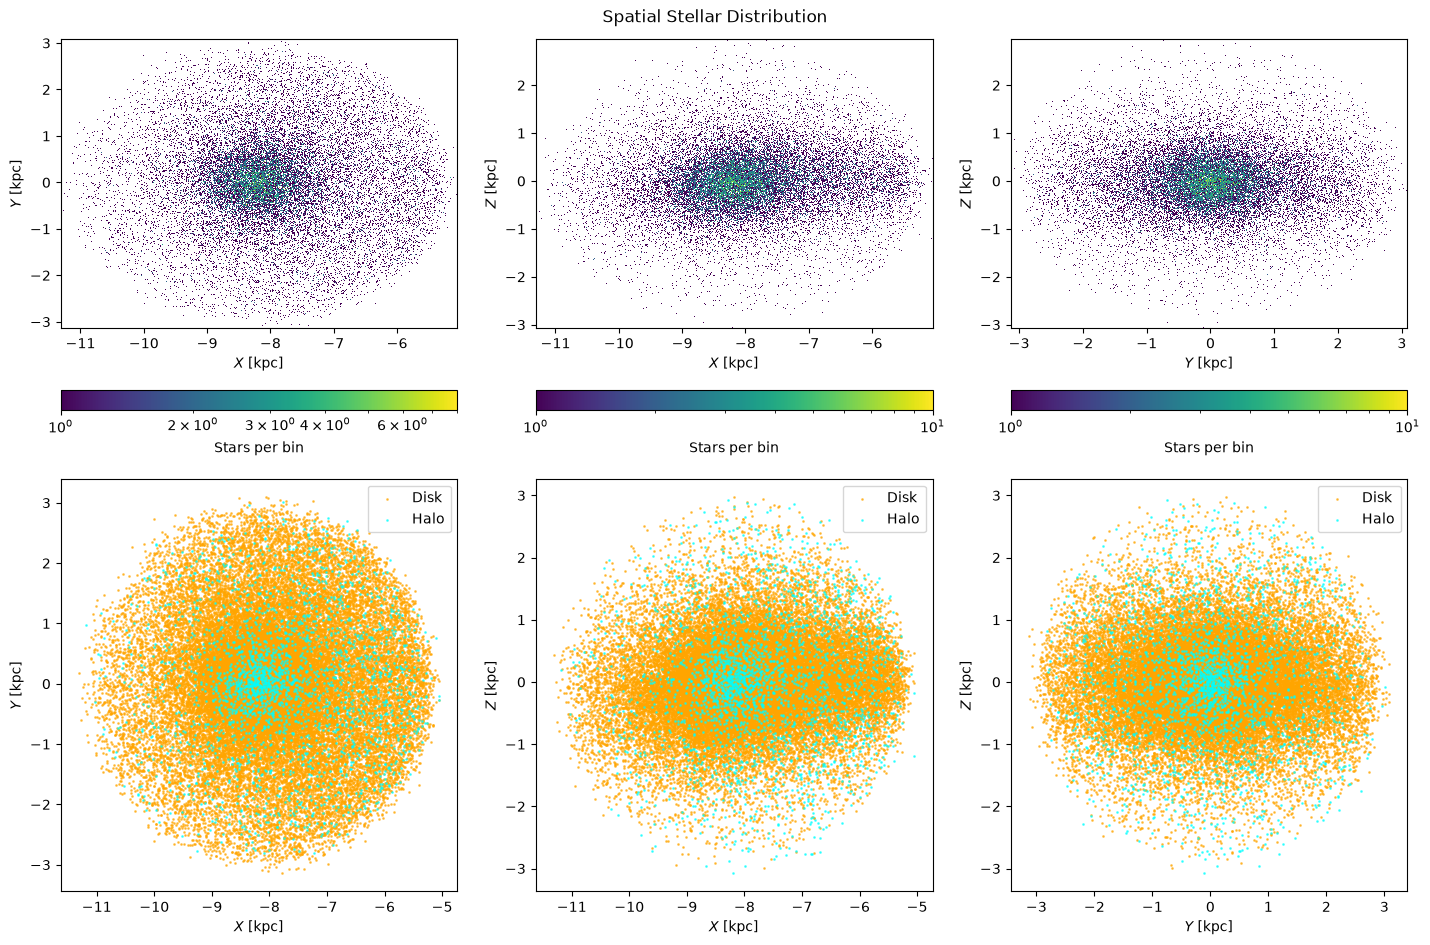

In [28]:
# Plotting spatial dist

plt.figure(figsize=(4.8*3, 4.8*2), layout='tight')
plt.suptitle('Spatial Stellar Distribution')
bins = 500

plt.subplot(2, 3, 1)
plt.hist2d(df['x'], df['y'], 
    bins=bins, 
    norm=LogNorm(), 
    cmap='viridis')
plt.colorbar(label='Stars per bin', orientation='horizontal')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Y$ [kpc]')

plt.subplot(2, 3, 2)
plt.hist2d(df['x'], df['z'], 
    bins=bins, 
    norm=LogNorm(), 
    cmap='viridis')
plt.colorbar(label='Stars per bin', orientation='horizontal')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Z$ [kpc]')

plt.subplot(2, 3, 3)
plt.hist2d(df['y'], df['z'], 
    bins=bins, 
    norm=LogNorm(), 
    cmap='viridis')
plt.colorbar(label='Stars per bin', orientation='horizontal')
plt.xlabel('$Y$ [kpc]')
plt.ylabel('$Z$ [kpc]')

mask_d = (df['labels'] == 0) 
mask_h = (df['labels'] == 1) 

plt.subplot(2, 3, 4)
plt.scatter(df['x'][mask_d], df['y'][mask_d], s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['x'][mask_h], df['y'][mask_h], s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Y$ [kpc]')
plt.legend()

plt.subplot(2, 3, 5)
plt.scatter(df['x'][mask_d], df['z'][mask_d], s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['x'][mask_h], df['z'][mask_h], s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Z$ [kpc]')
plt.legend()

plt.subplot(2, 3, 6)
plt.scatter(df['y'][mask_d], df['z'][mask_d], s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['y'][mask_h], df['z'][mask_h], s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.xlabel('$Y$ [kpc]')
plt.ylabel('$Z$ [kpc]')
plt.legend()


plt.show()

### 2.2 Cylindrycal Velocities 

In [29]:
# Converting velocities to cylindrical coordinates
# Inverting sign for U and V  due to left-hand convention

r = np.sqrt(df['x']**2 + df['y']**2)

df['u'] = - (df['x'] * df['vx'] + df['y'] * df['vy'])/r
df['v'] = - (df['x'] * df['vy'] - df['y'] * df['vx'])/r
df['w'] = df['vz']

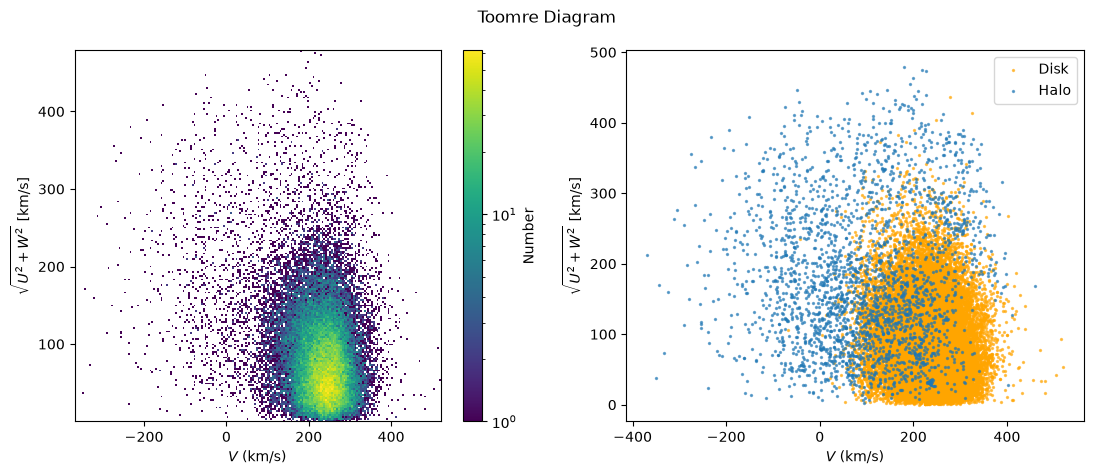

In [30]:
# Plotting tooomre diag.
plt.figure(figsize = (4.8*2.3,4.8*1), layout = 'tight')
plt.suptitle('Toomre Diagram')
bins = 200

plt.subplot(1,2,1)
plt.hist2d(df['vy'], np.sqrt(df['vx']**2 + df['vz']**2),
           bins = bins, norm = LogNorm())
plt.colorbar(label = 'Number', orientation = 'vertical')
plt.xlabel('$V$ (km/s)')
plt.ylabel('$\\sqrt{U^2 + W^2}$ [km/s]')

plt.subplot(1,2,2)
plt.scatter(df['vy'][mask_d], np.sqrt((df['vx'][mask_d])**2 + (df['vz'][mask_d])**2),
            s = 2, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['vy'][mask_h], np.sqrt((df['vx'][mask_h])**2 + (df['vz'][mask_h])**2),
            s = 2, alpha = 0.6, label = 'Halo')
plt.xlabel('$V$ (km/s)')
plt.ylabel('$\\sqrt{U^2 + W^2}$ [km/s]')
plt.legend()

plt.show()

#### Reading the velocity diagram

The labelled disk forms a tighter, largely prograde concentration, while the labelled halo spans a wider range of azimuthal and transverse motion, including low-rotation and retrograde stars. That contrast suggests kinematics can help distinguish the populations and might expose a dynamically distinct subset of halo stars.

## 2.2 Abundances

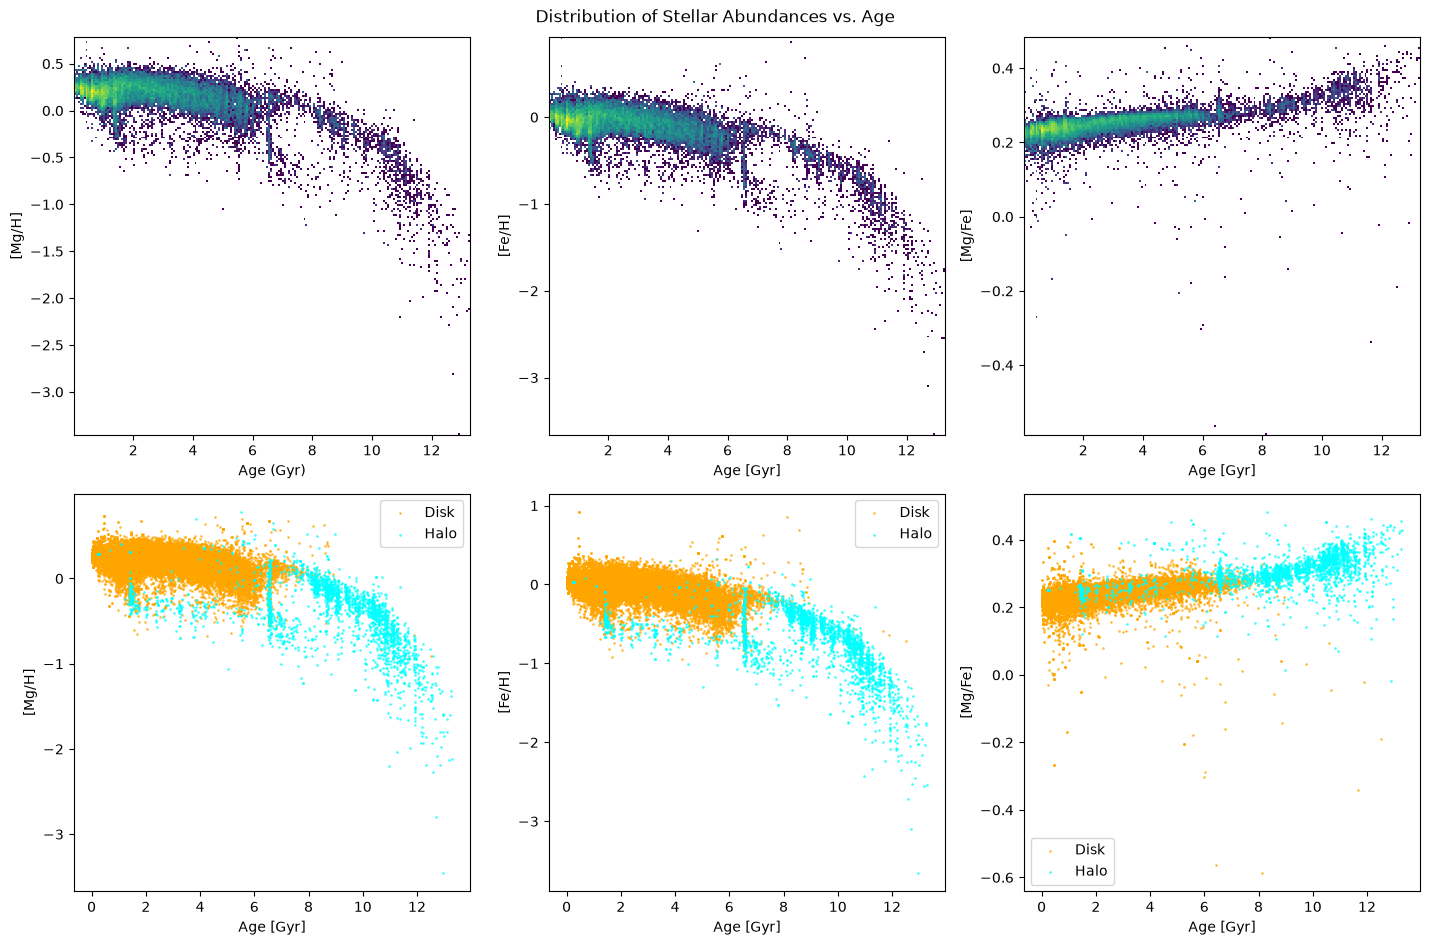

In [31]:
# Plotting abundances as function of age

plt.figure(figsize = (4.8*3,4.8*2), layout = 'tight')
plt.suptitle('Distribution of Stellar Abundances vs. Age')
bins = 200


plt.subplot(2,3,1)
plt.hist2d(df['age'], df['magnesium'], bins = bins, norm = LogNorm())
plt.xlabel('Age (Gyr)')
plt.ylabel('[Mg/H]')

plt.subplot(2,3,2)
plt.hist2d(df['age'], df['feh'], bins = bins, norm = LogNorm())
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')

plt.subplot(2,3,3)
plt.hist2d(df['age'], df['alpha'], bins = bins, norm = LogNorm())
plt.xlabel('Age [Gyr]')
plt.ylabel('[Mg/Fe]')

plt.subplot(2,3,4)
plt.scatter(df['age'][mask_d], df['magnesium'][mask_d],
            s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['age'][mask_h], df['magnesium'][mask_h],
            s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.legend()
plt.xlabel('Age [Gyr]')
plt.ylabel('[Mg/H]')

plt.subplot(2,3,5)
plt.scatter(df['age'][mask_d], df['feh'][mask_d],
            s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['age'][mask_h], df['feh'][mask_h],
            s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.legend()
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')

plt.subplot(2,3,6)
plt.scatter(df['age'][mask_d], df['alpha'][mask_d],
            s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['age'][mask_h], df['alpha'][mask_h],
            s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.legend()
plt.xlabel('Age [Gyr]')
plt.ylabel('[Mg/Fe]')

plt.show()

#### Reading chemistry against stellar age

The younger, labelled disk stars occupy a comparatively metal-rich region; older halo stars extend to lower $[\mathrm{Fe/H}]$ and $[\mathrm{Mg/H}]$, while $[\mathrm{Mg/Fe}]$ tends to be higher at older ages. The combined density panels can hide the sparser halo tail, which is clearer in the coloured panels. These age–abundance patterns are consistent with different enrichment histories and make chemistry useful for the later search. The visible bend or spread is a clue to examine for a dated merger.

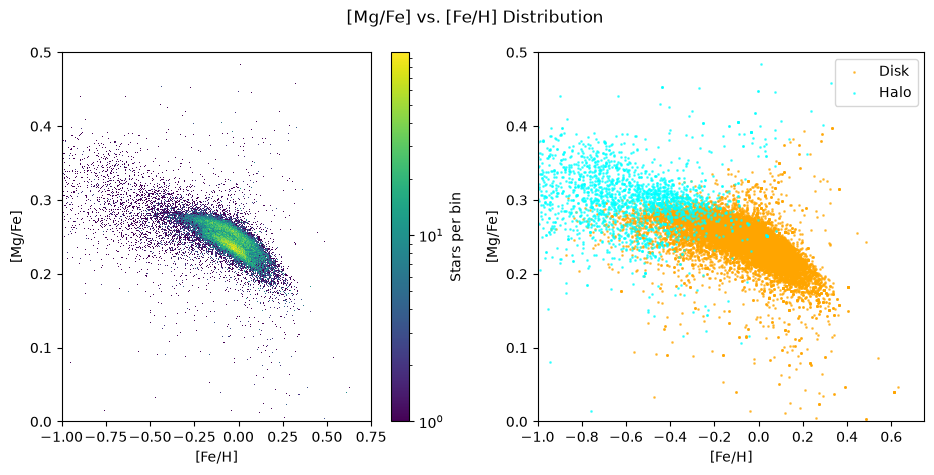

In [32]:
# Plotting alpha and metallicity dist.

plt.figure(figsize = (4.8*2,4.8), layout = 'tight')

plt.suptitle('[Mg/Fe] vs. [Fe/H] Distribution')

bins = 800
plt.subplot(1,2,1)
plt.hist2d(df['feh'], df['alpha'], bins = bins, norm =LogNorm())
plt.colorbar(label = 'Stars per bin', orientation = 'vertical')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1,0.75)
plt.ylim(0,0.5)

plt.subplot(1,2,2)
plt.scatter(df['feh'][mask_d], df['alpha'][mask_d],
            s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter(df['feh'][mask_h], df['alpha'][mask_h],
            s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.legend()
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1,0.75)
plt.ylim(0,0.5)

plt.show()

#### Reading the abundance plane

The main concentration runs from relatively metal-rich, lower-$[\mathrm{Mg/Fe}]$ stars toward more metal-poor, higher-$[\mathrm{Mg/Fe}]$ stars. Halo stars extend farther toward low $[\mathrm{Fe/H}]$ and show broader scatter, with overlap between the classes. A chemically unusual region could contain accreted stars, but chemistry alone does not identify their origin: stars formed in situ can overlap the same part of this plane. Age and kinematics provide the next independent checks. We can also see two bright yellow/green tracks in the left panel, that might indicate at different chemical evoluation tracks (accretion).

## 2.3 Stellar Ages

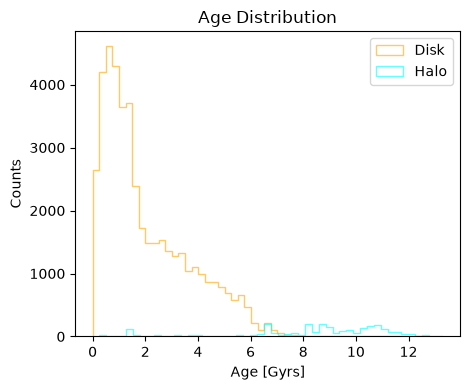

In [33]:
# Plotting age dist. of disk and halo
plt.figure(figsize = (4.8,4), layout = 'tight')

plt.hist(df['age'][mask_d],
         bins = 50, alpha = 0.6, color = 'orange', histtype='step', label='Disk')
plt.hist(df['age'][mask_h],
         bins = 50, alpha = 0.6, color = 'cyan', histtype='step', label='Halo')
plt.legend()
plt.title('Age Distribution')
plt.xlabel('Age [Gyrs]')
plt.ylabel('Counts')


plt.show()

#### Reading the age counts

The disk stars dominate the young bins, whereas the halo ones contribute proportionally more at older ages.Together with the abundance plots, they motivate looking for older, metal-poor, chemically distinct subsets.

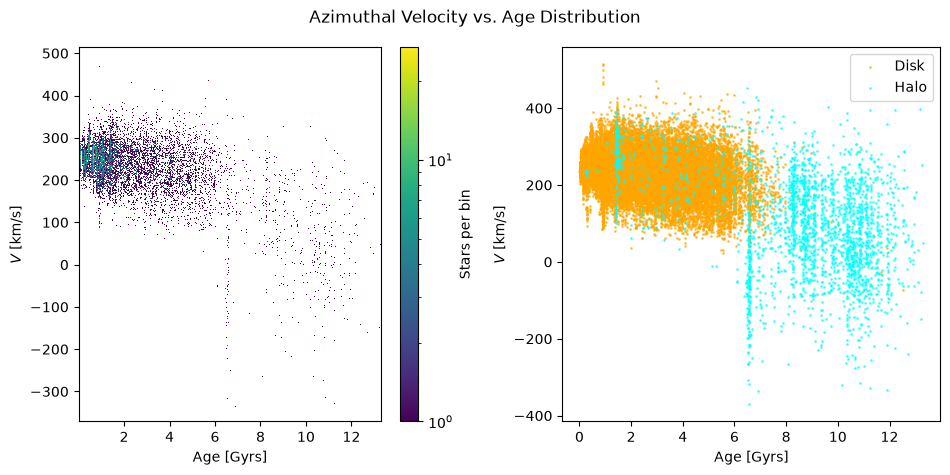

In [34]:
# Plotting v_az as a function of age

plt.figure(figsize = (4.8*2,4.8), layout = 'tight')

plt.suptitle('Azimuthal Velocity vs. Age Distribution')

bins = 800
plt.subplot(1,2,1)
plt.hist2d(df['age'], df['v'], bins = bins, norm =LogNorm())
plt.colorbar(label = 'Stars per bin', orientation = 'vertical')
plt.xlabel('Age [Gyrs]')
plt.ylabel('$V$ [km/s]')

plt.subplot(1,2,2)
plt.scatter( df['age'][mask_d], df['v'][mask_d],
            s = 1, alpha = 0.6, color = 'orange', label = 'Disk')
plt.scatter( df['age'][mask_h], df['v'][mask_h],
            s = 1, alpha = 0.6, color = 'cyan', label = 'Halo')
plt.legend()
plt.xlabel('Age [Gyrs]')
plt.ylabel('$V$ [km/s]')

plt.show()

#### Reading rotation against age

Younger disk stars cluster around strong prograde azimuthal motion. The older halo stars spreads to lower, near-zero, and sometimes opposite-sense rotation. Age and azimuthal velocity thus provide complementary clues: an old star with unusual rotation is a candidate for further investigation, but an individual retrograde orbit is not proof of accretion. 

## 2.4 Additional plots for presentation

Text(0, 0.5, 'Density')

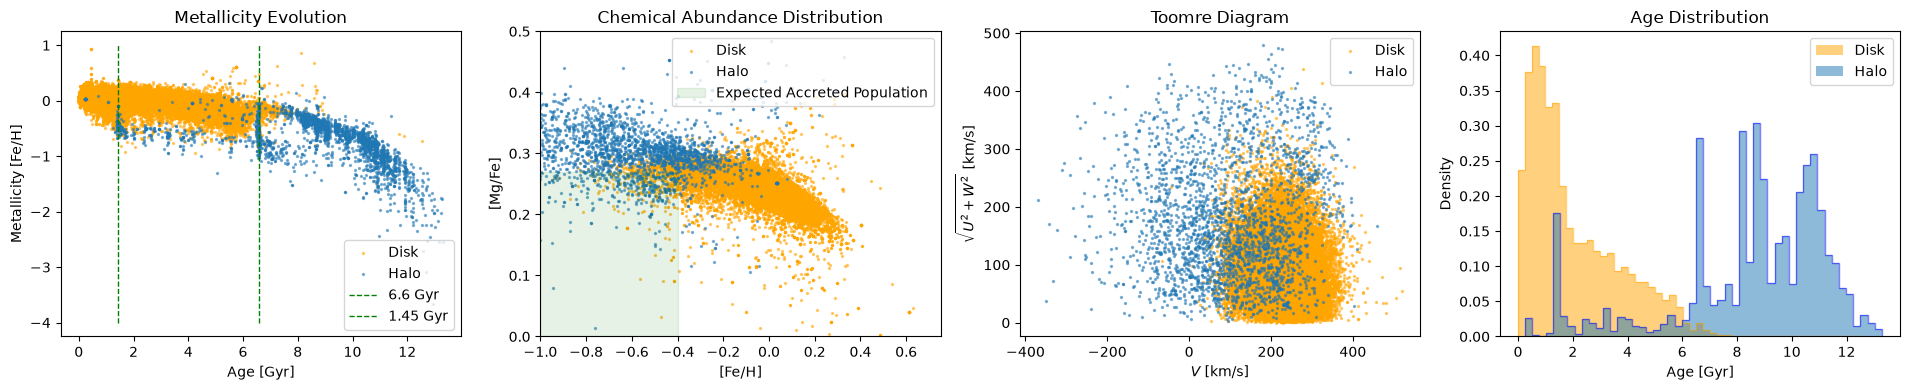

In [35]:
plt.figure(figsize = (4.8*4,4), layout = 'tight')


plt.subplot(1,4,1)
plt.scatter(df['age'][mask_d], df['feh'][mask_d],
            s = 2, alpha = 0.5, color = 'orange', label = 'Disk')
plt.scatter(df['age'][mask_h], df['feh'][mask_h],
            s = 2, alpha = 0.5, label = 'Halo')
plt.vlines(6.6, -4, 1, colors ='green', ls='--', lw = 1, alpha = 1, label='6.6 Gyr')
plt.vlines(1.45, -4, 1, ls='--', color = 'green', lw = 1, alpha = 1, label='1.45 Gyr')
plt.legend(loc = 'lower right')
plt.title('Metallicity Evolution')
plt.xlabel('Age [Gyr]')
plt.ylabel('Metallicity [Fe/H]')


plt.subplot(1,4,2)
plt.scatter(df['feh'][mask_d], df['alpha'][mask_d],
            s = 2, alpha = 0.5, color = 'orange', label = 'Disk')
plt.scatter(df['feh'][mask_h], df['alpha'][mask_h],
            s = 2, alpha = 0.5, label = 'Halo')
plt.title('Chemical Abundance Distribution')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1,0.75)
plt.ylim(0,0.5)

x = np.linspace(-1, -0.4, 500)  # x-range for the rectangle
y_lower = np.zeros_like(x)     # lower y-bound (0)
y_upper = np.full_like(x, 0.27)  # upper y-bound (0.27)
plt.fill_between(x, y_lower, y_upper, color = 'green', alpha = 0.1, label = 'Expected Accreted Population')
plt.legend(loc = 'upper right')

plt.subplot(1,4,3)
plt.scatter(df['vy'][mask_d], np.sqrt((df['vx'][mask_d])**2 + (df['vz'][mask_d])**2),
            s = 2, alpha = 0.5, color = 'orange', label = 'Disk')
plt.scatter(df['vy'][mask_h], np.sqrt((df['vx'][mask_h])**2 + (df['vz'][mask_h])**2),
            s = 2, alpha = 0.5, label = 'Halo')
plt.title('Toomre Diagram')
plt.xlabel('$V$ [km/s]')
plt.ylabel('$\\sqrt{U^2 + W^2}$ [km/s]')
plt.legend()


plt.subplot(1,4,4)
plt.hist(df['age'][mask_d],
         bins = 50, alpha = 0.5, color = 'orange', histtype='stepfilled', label='Disk', density = True)
plt.hist(df['age'][mask_d],
         bins = 50, alpha = 0.5, color = 'orange', histtype='step', density = True)
plt.hist(df['age'][mask_h],
         bins = 50, alpha = 0.5, histtype='stepfilled', label='Halo', density = True)
plt.hist(df['age'][mask_h],
         bins = 50, alpha = 0.5, histtype ='step', color = 'blue', density = True)
plt.legend()
plt.title('Age Distribution')
plt.xlabel('Age [Gyr]')
plt.ylabel('Density')

## 2.5: Pair Plot and Correlation Matrix

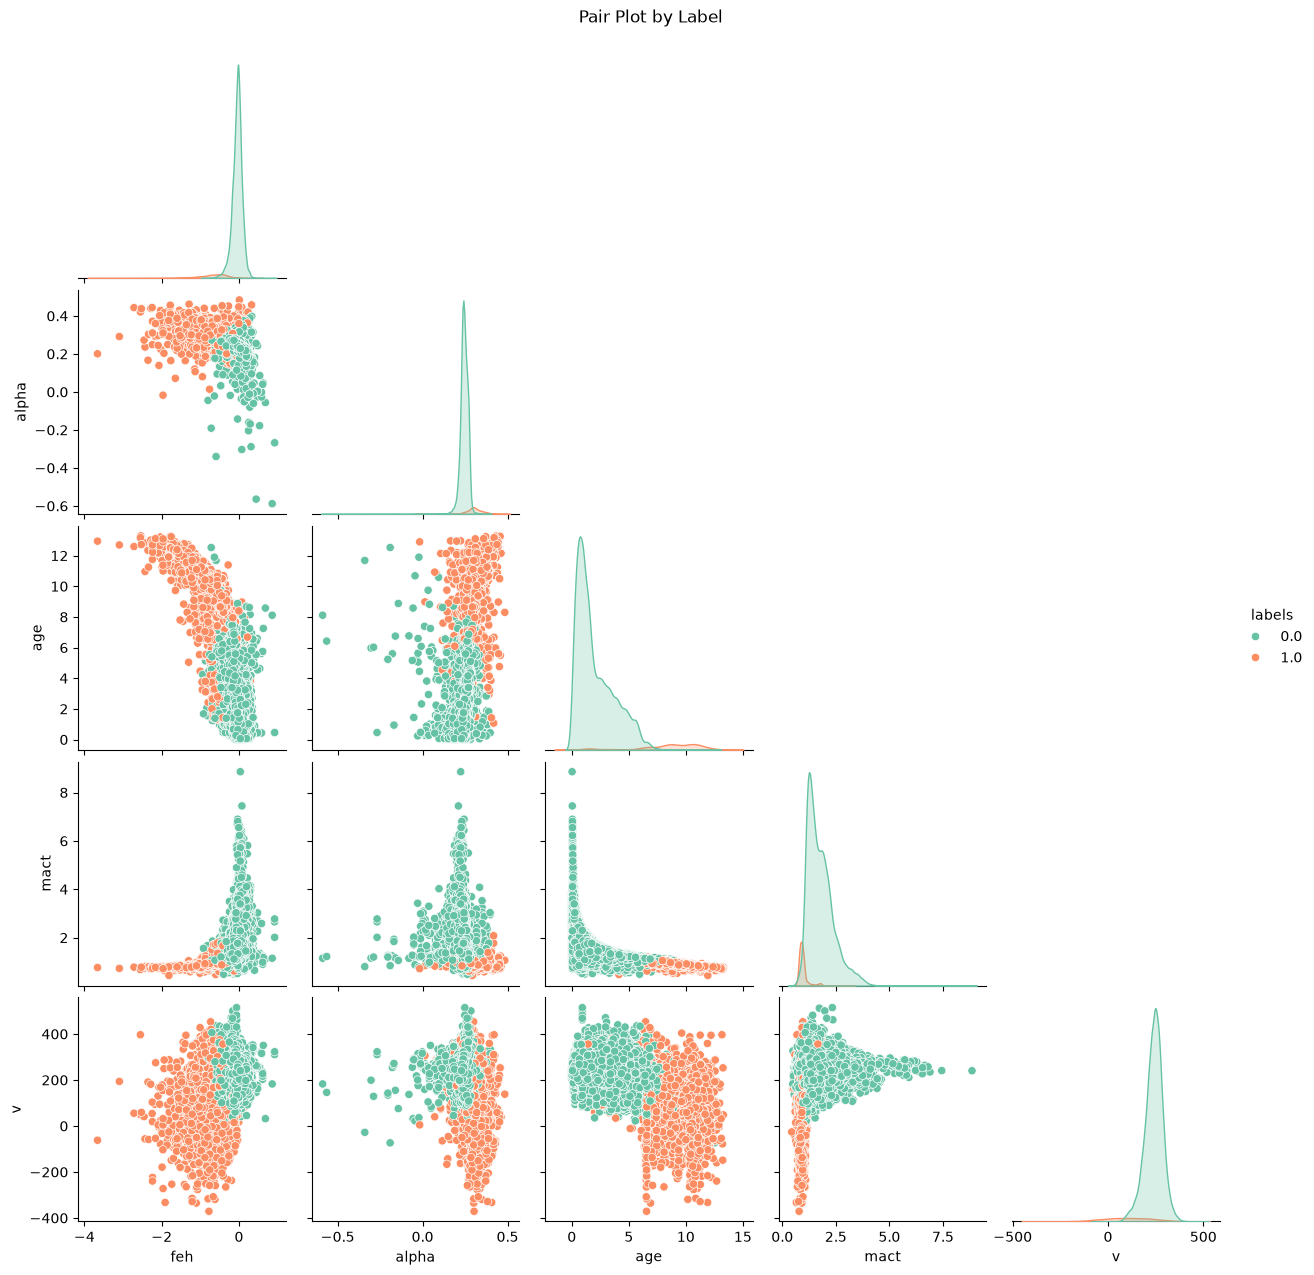

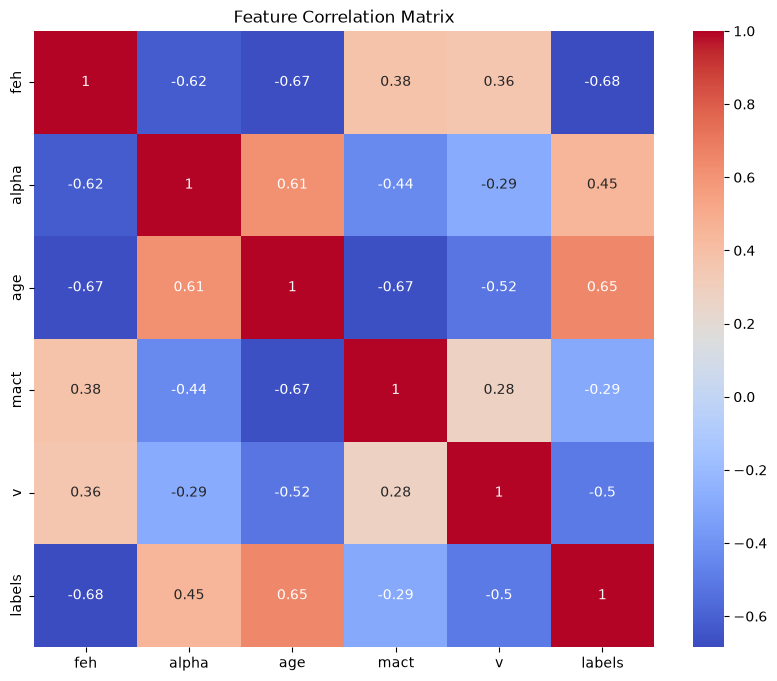

In [36]:
# Pair plot by population
sns.pairplot(df, vars = ['feh', 'alpha', 'age', 'mact', 'v'], hue = 'labels', palette = 'Set2', corner = True)
plt.suptitle("Pair Plot by Label", y = 1.02)
plt.show()

# Correlation matrix
plt.figure(figsize = (10,8))
sns.heatmap(df[['feh', 'alpha', 'age', 'mact', 'v', 'labels']].corr(), annot = True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# 3. Task 1: Supervised ML


📊 Using Feature Set: Without Engineered Features

🔍 Model: SVC


c:\Users\marya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Test Set Report:
              precision    recall  f1-score   support

        Disk       0.99      1.00      0.99      6364
        Halo       0.95      0.87      0.91       370

    accuracy                           0.99      6734
   macro avg       0.97      0.93      0.95      6734
weighted avg       0.99      0.99      0.99      6734

Validation Set Report:
              precision    recall  f1-score   support

        Disk       0.99      1.00      1.00      6364
        Halo       0.95      0.88      0.92       371

    accuracy                           0.99      6735
   macro avg       0.97      0.94      0.96      6735
weighted avg       0.99      0.99      0.99      6735


🔍 Model: Random Forest

Test Set Report:
              precision    recall  f1-score   support

        Disk       1.00      1.00      1.00      6364
        Halo       0.95      0.92      0.93       370

    accuracy                           0.99      6734
   macro avg       0.97      0.96      0.97  

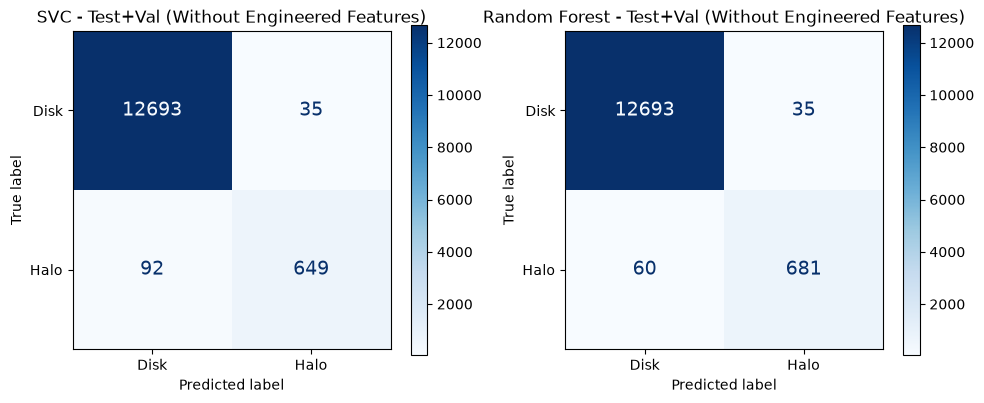


📊 Using Feature Set: With Engineered Features

🔍 Model: SVC


c:\Users\marya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Test Set Report:
              precision    recall  f1-score   support

        Disk       1.00      1.00      1.00      6364
        Halo       0.98      0.98      0.98       370

    accuracy                           1.00      6734
   macro avg       0.99      0.99      0.99      6734
weighted avg       1.00      1.00      1.00      6734

Validation Set Report:
              precision    recall  f1-score   support

        Disk       1.00      1.00      1.00      6364
        Halo       0.97      0.97      0.97       371

    accuracy                           1.00      6735
   macro avg       0.98      0.99      0.98      6735
weighted avg       1.00      1.00      1.00      6735


🔍 Model: Random Forest

Test Set Report:
              precision    recall  f1-score   support

        Disk       1.00      1.00      1.00      6364
        Halo       0.98      0.98      0.98       370

    accuracy                           1.00      6734
   macro avg       0.99      0.99      0.99  

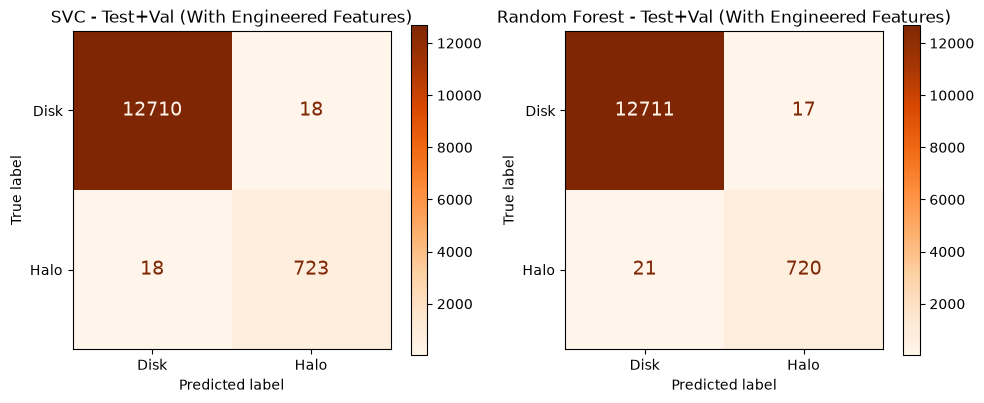

In [37]:
# Feature selection, scaling, and data splitting (with and w/o DE)
feature_sets = {
    'Without Engineered Features': ['feh', 'alpha', 'age', 'magnesium'],
    'With Engineered Features': ['v', 'u', 'w', 'feh', 'alpha', 'age', 'magnesium']
}

# Specifying  models
models = {
    'SVC': SVC(probability=True, kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Creating a dictionary
learning_data = {model: {} for model in models}

# Loop, runs over non-DE and DE features, makes class. table, and conf. matirx
for feature_label, feature_list in feature_sets.items():
    print(f"\n{'='*60}\n📊 Using Feature Set: {feature_label}\n{'='*60}")
    
    X = df[feature_list]
    y = df['labels']

    # Scaling features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5:1:1 split → Train: 71.4%, Test: 14.3%, Val: 14.3%
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y, test_size = 2/7, stratify = y, random_state = 42
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = 42
    )

    # Creating plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    for i, (model_name, model) in enumerate(models.items()):
        print(f"\n🔍 Model: {model_name}")

        # Train
        model.fit(X_train, y_train)

        # Predictions
        y_pred_test = model.predict(X_test)
        y_pred_val = model.predict(X_val)
        
        # Combine test + validation
        y_true_combined = np.concatenate([y_test, y_val])
        y_pred_combined = np.concatenate([y_pred_test, y_pred_val])
        
        # Confusion matrix: Test + Validation 

        # Using if statement to have different colors for w and w/o DE sets
        if feature_label == 'Without Engineered Features':
            cmap_clr = 'Blues'
        else:
            cmap_clr = 'Oranges'
            
        cm = confusion_matrix(y_true_combined, y_pred_combined)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Disk', 'Halo'])
        disp.plot(ax=ax[i], cmap = cmap_clr, values_format = 'd', text_kw={'fontsize': 14})
        ax[i].set_title(f'{model_name} - Test+Val ({feature_label})')
        ax[i].grid(False)
        

        # Classification reports
        print("\nTest Set Report:")
        print(classification_report(y_test, y_pred_test, target_names=['Disk', 'Halo']))

        print("Validation Set Report:")
        print(classification_report(y_val, y_pred_val, target_names=['Disk', 'Halo']))

 # Commenting the learning score curve because it takes a lot of time to run
        # Learning curve
        # Select learning score here
        #train_sizes, train_scores, val_scores = learning_curve(
            #model, X_scaled, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
        #)
        #learning_data[model_name][feature_label] = (train_sizes, train_scores, val_scores)

    plt.tight_layout()
    plt.show()

# Function for plotting learning curve
def plot_learning_curves(model_name):
    fig, ax = plt.subplots(figsize=(8, 6))
    for feature_label in feature_sets:
        train_sizes, train_scores, val_scores = learning_data[model_name][feature_label]
        train_mean = np.mean(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)

        ax.plot(train_sizes, train_mean, label=f'{feature_label} - Train', linestyle='--')
        ax.plot(train_sizes, val_mean, label=f'{feature_label} - Validation')

    ax.set_title(f'Learning Curve: {model_name}')
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

#plot_learning_curves('SVC')
#plot_learning_curves('Random Forest')


# 4. Task 2: Unsupervised ML

## 4.1 Dimensionalit reduction with TSNE

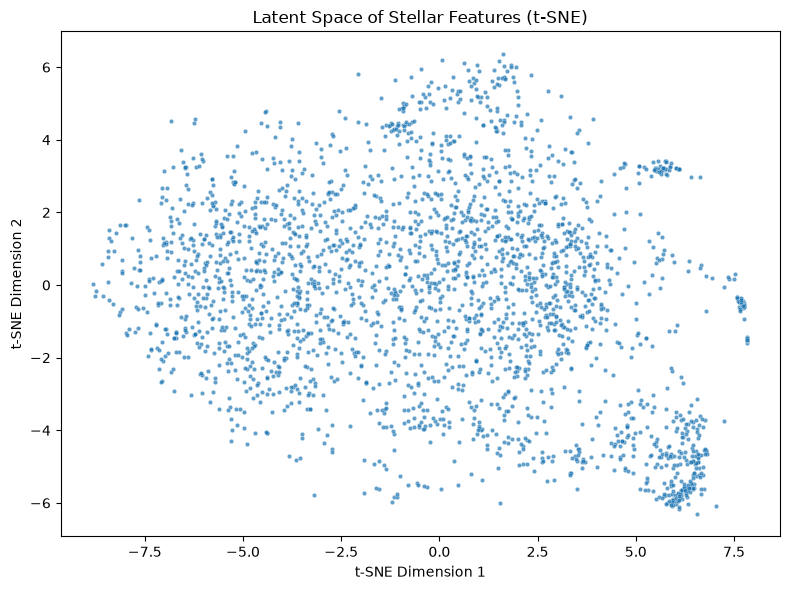

In [38]:
# Filtering halo stars and sik stars
halo_df = df[df['labels'] == 1].copy()
disk_df = df[df['labels'] == 0].copy()
features = ['age', 'alpha', 'feh', 'u', 'v', 'w']
X_halo = halo_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_halo)

# Running t-SNE
perp = 500
tsne = TSNE(n_components = 2, perplexity = perp, random_state = 42)
X_tsne = tsne.fit_transform(X_scaled)

# Add t-SNE result to DataFrame
halo_df = halo_df.loc[X_halo.index].copy()
halo_df['tsne_1'] = X_tsne[:, 0]
halo_df['tsne_2'] = X_tsne[:, 1]

# Visualize
plt.figure(figsize=(8, 6))
sns.scatterplot(data=halo_df, x='tsne_1', y='tsne_2', s=10, alpha=0.7)
plt.title("Latent Space of Stellar Features (t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()

## 4.2 Clustering with DBSCAN

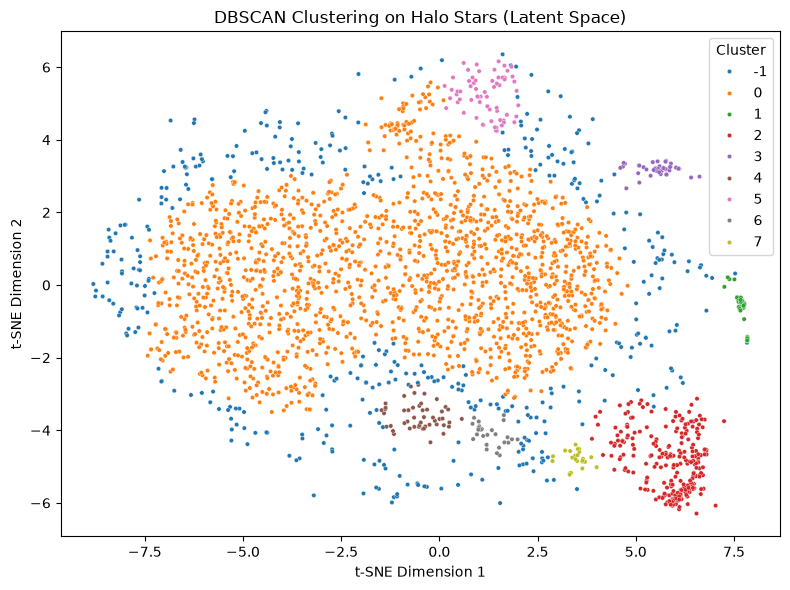

In [39]:
# Use the same t-SNE results (X_tsne)
eps = 0.6
ms = 23
dbscan = DBSCAN(eps = eps, min_samples = ms)  # You may tune eps
halo_df['dbscan_cluster'] = dbscan.fit_predict(X_tsne)

# Visualize
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=halo_df,
    x='tsne_1', y='tsne_2',
    hue='dbscan_cluster', palette='tab10', s=10
)
plt.title('DBSCAN Clustering on Halo Stars (Latent Space)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

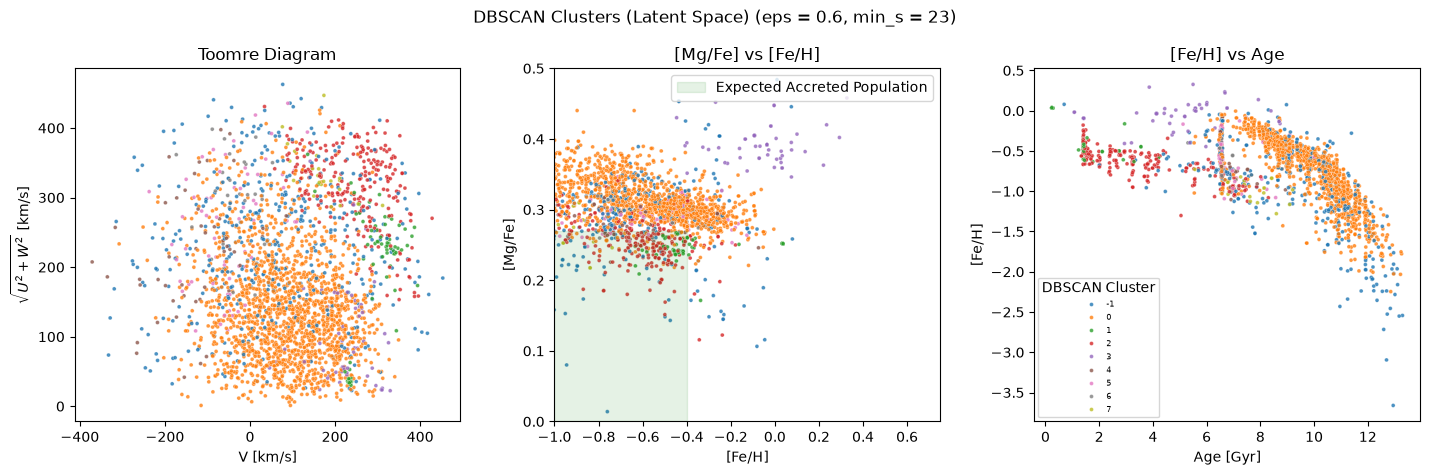

In [40]:
## Reminder to self: turn this into a function

halo_df['toomre'] = np.sqrt(halo_df['u']**2 + halo_df['w']**2)


plt.figure(figsize=(4.8*3, 4.8))
plt.suptitle(f'DBSCAN Clusters (Latent Space) (eps = {eps}, min_s = {ms})')


plt.subplot(1, 3, 1)
sns.scatterplot(
    data=halo_df,
    x='v', y='toomre',
    hue='dbscan_cluster', palette='tab10', s=8, alpha=0.8, legend=False
)
plt.title('Toomre Diagram')
plt.xlabel('V [km/s]')
plt.ylabel(r'$\sqrt{U^2 + W^2}$ [km/s]')


plt.subplot(1, 3, 2)
sns.scatterplot(
    data=halo_df,
    x='feh', y='alpha',
    hue='dbscan_cluster', palette='tab10', s=8, alpha=0.8, legend=False
)
plt.title('[Mg/Fe] vs [Fe/H]')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1,0.75)
plt.ylim(0,0.5)

x = np.linspace(-1, -0.4, 500)  # x-range for the rectangle
y_lower = np.zeros_like(x)     # lower y-bound (0)
y_upper = np.full_like(x, 0.27)  # upper y-bound (0.27)
plt.fill_between(x, y_lower, y_upper, color = 'green', alpha = 0.1, label = 'Expected Accreted Population')
plt.legend(loc = 'upper right')


plt.subplot(1, 3, 3)
sns.scatterplot(
    data=halo_df,
    x='age', y='feh',
    hue='dbscan_cluster', palette='tab10', s=8, alpha=0.8
)
plt.title('[Fe/H] vs Age')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.legend(title='DBSCAN Cluster', loc='best', fontsize=6)


plt.tight_layout(h_pad=1.4)
plt.show()

In [41]:
print(silhouette_score(X_tsne, halo_df['dbscan_cluster']),
      davies_bouldin_score(X_tsne, halo_df['dbscan_cluster']),
      calinski_harabasz_score(X_tsne, halo_df['dbscan_cluster']))

-0.01843910478055477 3.655955206785544 252.27406162932644


## DBSCAN on Original Space

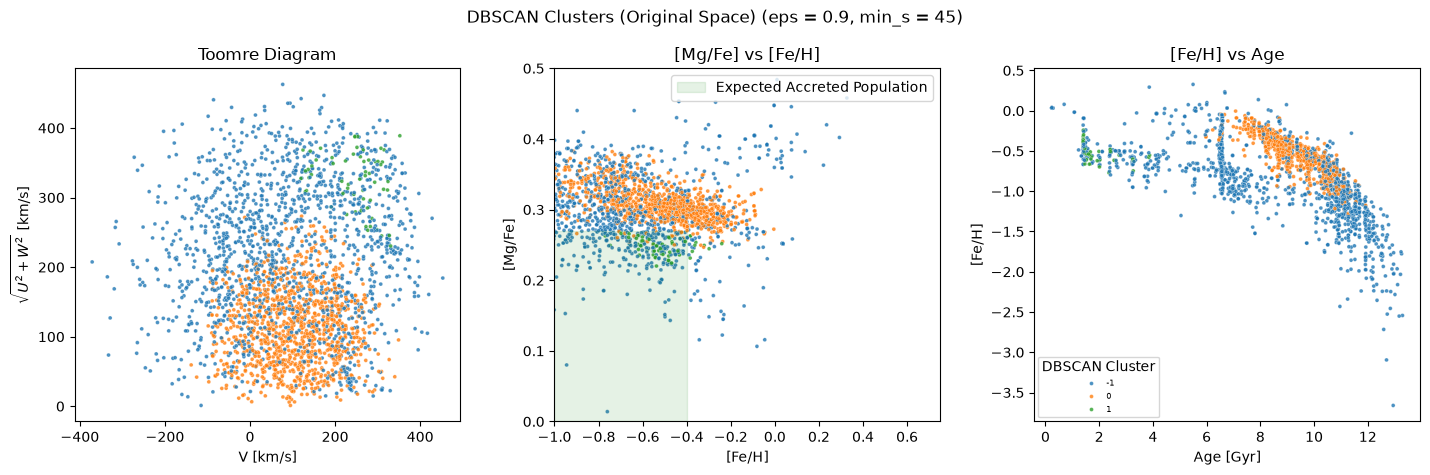

In [42]:
eps = 0.9
ms = 45
dbscan = DBSCAN(eps = eps, min_samples = ms)  # You may tune eps
halo_df['dbscan_cluster_o'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(4.8*3, 4.8))
plt.suptitle(f'DBSCAN Clusters (Original Space) (eps = {eps}, min_s = {ms})')


plt.subplot(1, 3, 1)
sns.scatterplot(
    data=halo_df,
    x='v', y='toomre',
    hue='dbscan_cluster_o', palette='tab10', s=8, alpha=0.8, legend=False
)
plt.title('Toomre Diagram')
plt.xlabel('V [km/s]')
plt.ylabel(r'$\sqrt{U^2 + W^2}$ [km/s]')


plt.subplot(1, 3, 2)
sns.scatterplot(
    data=halo_df,
    x='feh', y='alpha',
    hue='dbscan_cluster_o', palette='tab10', s=8, alpha=0.8, legend=False
)
plt.title('[Mg/Fe] vs [Fe/H]')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1,0.75)
plt.ylim(0,0.5)

x = np.linspace(-1, -0.4, 500)  # x-range for the rectangle
y_lower = np.zeros_like(x)     # lower y-bound (0)
y_upper = np.full_like(x, 0.27)  # upper y-bound (0.27)
plt.fill_between(x, y_lower, y_upper, color = 'green', alpha = 0.1, label = 'Expected Accreted Population')
plt.legend(loc = 'upper right')


plt.subplot(1, 3, 3)
sns.scatterplot(
    data=halo_df,
    x='age', y='feh',
    hue='dbscan_cluster_o', palette='tab10', s=8, alpha=0.8
)
plt.title('[Fe/H] vs Age')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.legend(title='DBSCAN Cluster', loc='best', fontsize=6)


plt.tight_layout(h_pad=1.4)
plt.show()

In [43]:
print(silhouette_score(X_scaled, halo_df['dbscan_cluster_o']),
      davies_bouldin_score(X_scaled, halo_df['dbscan_cluster_o']),
      calinski_harabasz_score(X_scaled, halo_df['dbscan_cluster_o']))

0.050338388559776424 3.5057334571251535 111.07209091105132


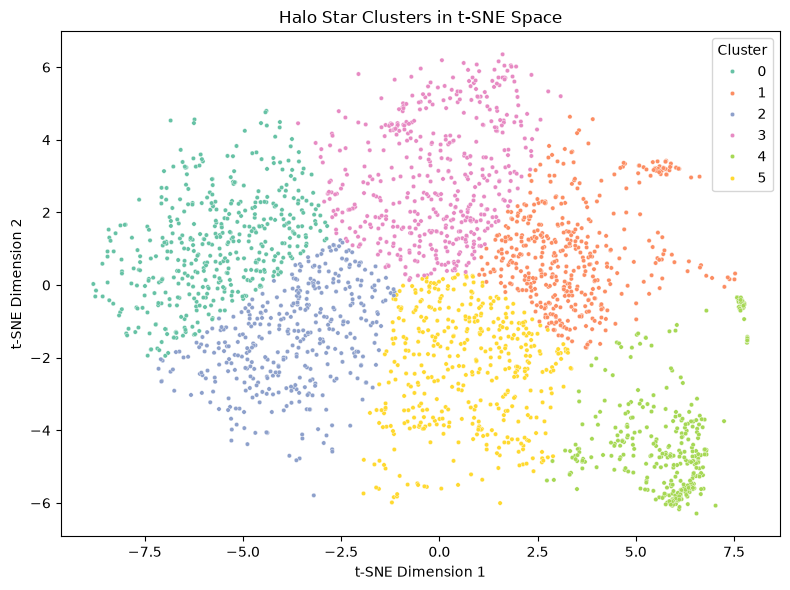

In [44]:
from sklearn.cluster import KMeans

# Try 3 clusters 
kmeans = KMeans(n_clusters = 6, random_state = 42)
halo_df['cluster'] = kmeans.fit_predict(X_tsne)

# Plot with clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=halo_df, x='tsne_1', y='tsne_2', hue='cluster', palette='Set2', s=10)
plt.title("Halo Star Clusters in t-SNE Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

### 4.2.1: Visualising Kmeans

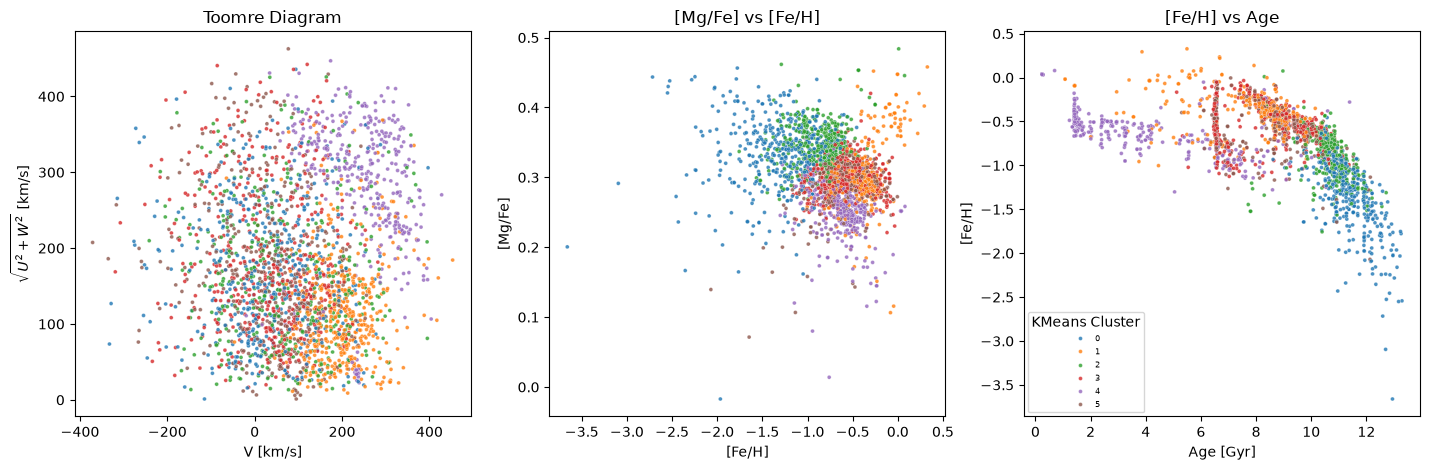

In [45]:

halo_df['toomre'] = np.sqrt(halo_df['u']**2 + halo_df['w']**2)

plt.figure(figsize=(4.8*3, 4.8))


plt.subplot(1, 3, 1)
sns.scatterplot(
    data=halo_df,
    x='v', y='toomre',
    hue='cluster', palette='tab10', s=8, alpha=0.8, legend=False
)
plt.title('Toomre Diagram')
plt.xlabel('V [km/s]')
plt.ylabel(r'$\sqrt{U^2 + W^2}$ [km/s]')


plt.subplot(1, 3, 2)
sns.scatterplot(
    data=halo_df,
    x='feh', y='alpha',
    hue='cluster', palette='tab10', s=8, alpha=0.8, legend=False
)
plt.title('[Mg/Fe] vs [Fe/H]')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')


plt.subplot(1, 3, 3)
sns.scatterplot(
    data=halo_df,
    x='age', y='feh',
    hue='cluster', palette='tab10', s=8, alpha=0.8
)
plt.title('[Fe/H] vs Age')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.legend(title='KMeans Cluster', loc='best', fontsize=6)


plt.tight_layout(h_pad=1.4)
plt.show()


In [46]:
len(df)

47141